# Notebook 05 — Controle Contínuo: DDPG e SAC

**Disciplina:** Modelos de Aprendizagem por Reforço  
**Aula:** 03 — Policy-Based Methods  
**Ambiente:** Pendulum-v1 (Gymnasium)  
**Bibliotecas:** numpy, matplotlib, gymnasium, torch

| | |
|---|---|
| **Aula** | Aula 03 — Métodos Baseados em Políticas |
| **Notebook** | 05 — Controle Contínuo: DDPG e SAC |
| **Seções** | 3.7–3.8 |
| **Tempo de leitura** | ~15 min |
| **Tempo de execução** | ~5 min |

**Pré-requisitos:** Notebook 04 desta aula (PPO); conceito de espaço de ações contínuo.

**Competências para o Desafio Final:** Distinguir DDPG e SAC; compreender por que ações contínuas exigem algoritmos específicos e como a entropia máxima melhora a exploração.

---

### Recapitulando

No Notebook 04, PPO controlou o tamanho das atualizações via clipping da razão de probabilidades π_novo/π_antigo, tornando o treinamento mais estável e reprodutível. Porém, PPO opera sobre distribuições categóricas — em ambientes com **ações contínuas** (torque, velocidade, ângulo), é necessária uma família diferente de algoritmos.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../.."))

import rl_utils
rl_utils.info_versoes()
rl_utils.configurar_matplotlib()
rl_utils.definir_seeds(42)
dispositivo = rl_utils.obter_dispositivo(usar_gpu=True)

Biblioteca           Versão
--------------------------------
gymnasium            1.0.0
torch                2.11.0+cu130
numpy                2.4.2
matplotlib           3.10.8
pandas               3.0.1
scikit-learn         1.8.0
Dispositivo em uso: cuda


## Bloco 1 — Contexto e pergunta central

Os algoritmos anteriores (REINFORCE, A2C, PPO) usam políticas **estocásticas sobre ações discretas** — o ator produz uma distribuição categórica sobre um conjunto finito de ações. Isso funciona no CartPole, onde as ações são {empurrar esquerda, empurrar direita}.

Em controle de robôs, veículos autônomos e simulação física, as ações são **valores contínuos**: torque aplicado a uma junta, ângulo de direção, força num eixo. Uma distribuição categórica sobre um espaço contínuo não faz sentido.

> **"Como um agente pode aprender a produzir ações contínuas de forma eficiente?"**

Este notebook apresenta duas abordagens complementares:

- **DDPG** (*Deep Deterministic Policy Gradient*): política determinística + ruído de exploração externo + *replay buffer off-policy* (pode reutilizar experiências coletadas por políticas anteriores).
- **SAC** (*Soft Actor-Critic*): política estocástica Gaussiana + maximização de entropia como parte do objetivo.

## Bloco 2 — Mini teoria

### Por que ações contínuas mudam tudo

Nos algoritmos anteriores (REINFORCE, A2C, PPO), as ações eram discretas: {esquerda, direita} no CartPole. Para escolher a melhor ação, bastava comparar Q(s, esquerda) com Q(s, direita) e pegar o maior.

Em robótica e controle, as ações são **valores contínuos**: quanto de torque aplicar (qualquer número real entre −2.0 e +2.0 N·m no Pendulum), em qual ângulo girar, com qual força pressionar. Não é possível listar todas as ações e comparar — há infinitos valores possíveis.

> **Solução:** em vez de avaliar todas as ações, ensinar a rede a *gerar diretamente* a ação — como um piloto que aprende a ajustar o volante de forma contínua, não a comparar posições discretas.

---

### DDPG — quatro componentes trabalhando juntos

**Ator** — dada uma observação, gera diretamente o torque a aplicar:
```
estado → [rede neural] → ação (valor real contínuo)
```

**Crítico** — avalia a qualidade de um par (estado, ação):
```
(estado + ação) → [rede neural] → Q(estado, ação)
```
O ator aprende a gerar ações que *maximizam* o que o crítico avalia. O gradiente flui do crítico para o ator — o crítico "ensina" o ator em qual direção melhorar.

**Replay buffer** — um banco de experiências passadas. Em vez de aprender de uma transição por vez, o DDPG armazena milhares de transições `(estado, ação, recompensa, próximo_estado)` e aprende em mini-batches aleatórios. Isso quebra correlações temporais e aumenta a eficiência amostral.

**Redes-alvo** (*target networks*) — cópias "congeladas" do ator e do crítico que se atualizam muito lentamente (τ=0.005 por passo). Sem elas, o alvo de treinamento mudaria a cada passo junto com a rede, criando instabilidade — como tentar acertar um alvo em movimento constante.

**Exploração** — como a política é determinística (gera sempre a mesma ação para o mesmo estado), o DDPG adiciona ruído gaussiano durante a coleta de dados, permitindo que o agente experimente variações ao redor da ação atual.

O diagrama na próxima célula mostra como esses componentes se conectam — execute-a antes de continuar.

---

### SAC — exploração como objetivo, não como ruído externo

O SAC reformula o problema de exploração. Em vez de adicionar ruído manualmente com um σ fixo, a **entropia da política** (o grau de aleatoriedade das ações) vira parte do que o agente maximiza:

```
maximizar:  recompensa acumulada  +  α × entropia da política
```

O agente aprende a ser aleatório *quando não tem certeza* e determinístico *quando já sabe o que fazer* — emergindo naturalmente do treinamento, sem precisar ajustar nenhum σ.

Uma adição técnica importante: o SAC usa **dois críticos independentes** e sempre toma o mínimo dos dois. Isso evita que o ator explore avaliações superestimadas de Q — um problema frequente no DDPG.

---

### Comparação rápida

| Aspecto | DDPG | SAC |
|---|---|---|
| Tipo de política | Determinística | Estocástica (Gaussiana) |
| Exploração | Ruído externo (σ fixo) | Maximização de entropia |
| Sensibilidade a hiperparâmetros | Alta | Baixa |
| Consistência nos benchmarks | Moderada | Alta |

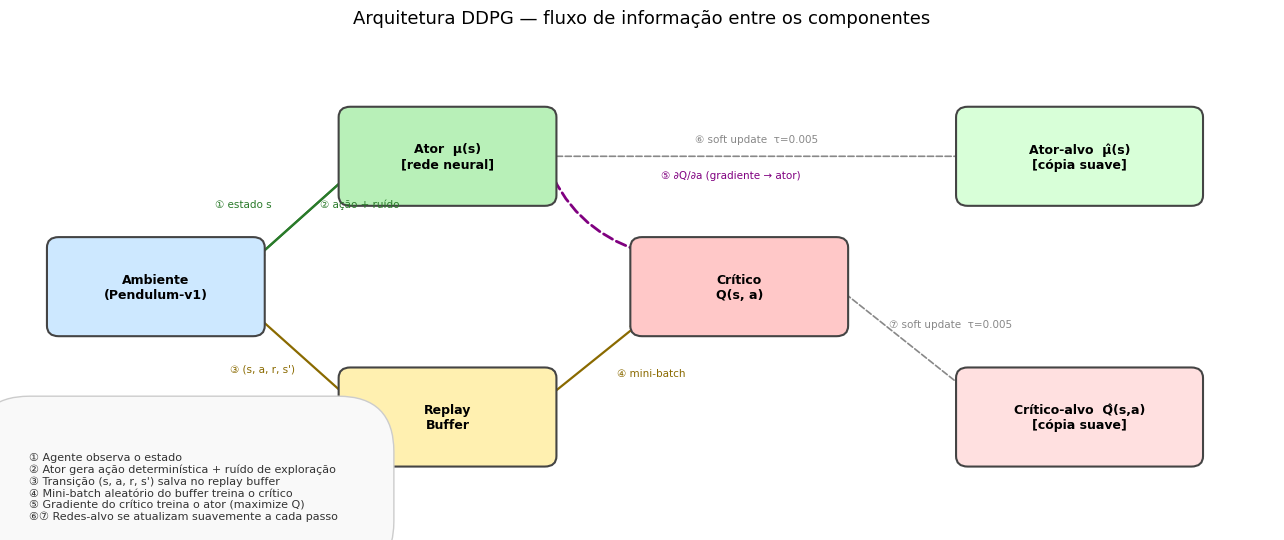

In [2]:
# ── Diagrama: arquitetura DDPG — como os quatro componentes se conectam ──
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.set_xlim(0, 13); ax.set_ylim(0, 5.5); ax.axis("off")
fig.suptitle("Arquitetura DDPG — fluxo de informação entre os componentes", fontsize=13)

def box(ax, cx, cy, texto, cor, w=2.0, h=0.9):
    rect = mpatches.FancyBboxPatch(
        (cx - w/2, cy - h/2), w, h,
        boxstyle="round,pad=0.12",
        facecolor=cor, edgecolor="#444", linewidth=1.5, zorder=3)
    ax.add_patch(rect)
    ax.text(cx, cy, texto, ha="center", va="center",
            fontsize=9, fontweight="bold", zorder=4, multialignment="center")

def seta(ax, x1, y1, x2, y2, label="", cor="black", lw=1.6, lbl_off=(0, 0.14), ls="-"):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1), zorder=2,
                arrowprops=dict(arrowstyle="->", color=cor, lw=lw, linestyle=ls))
    if label:
        mx, my = (x1 + x2) / 2 + lbl_off[0], (y1 + y2) / 2 + lbl_off[1]
        ax.text(mx, my, label, fontsize=7.5, color=cor, ha="center", zorder=5)

# Blocos principais
box(ax,  1.5, 2.8, "Ambiente\n(Pendulum-v1)",   "#cde8ff")
box(ax,  4.5, 4.3, "Ator  μ(s)\n[rede neural]", "#b8f0b8")
box(ax,  4.5, 1.3, "Replay\nBuffer",             "#fff0b0")
box(ax,  7.5, 2.8, "Crítico\nQ(s, a)",           "#ffc8c8")
box(ax, 11.0, 4.3, "Ator-alvo  μ̂(s)\n[cópia suave]",    "#d8ffd8", w=2.3)
box(ax, 11.0, 1.3, "Crítico-alvo  Q̂(s,a)\n[cópia suave]", "#ffe0e0", w=2.3)

# ① Ambiente → Ator (estado)
seta(ax, 2.5, 3.1, 3.5, 4.1, "① estado s", "#2a7a2a", lbl_off=(-0.6, 0.12))
# ② Ator → Ambiente (ação + ruído)
seta(ax, 3.5, 4.1, 2.5, 3.1, "② ação + ruído", "#2a7a2a", lbl_off=(0.6, 0.12))
# ③ Ambiente → Replay Buffer
seta(ax, 2.5, 2.5, 3.5, 1.5, "③ (s, a, r, s')", "#8a6a00", lbl_off=(-0.4, -0.18))
# ④ Replay Buffer → Crítico
seta(ax, 5.5, 1.5, 6.5, 2.4, "④ mini-batch", "#8a6a00", lbl_off=(0.6, -0.18))
# ⑤ Crítico → Ator (gradiente)
ax.annotate("", xy=(5.5, 4.3), xytext=(6.5, 3.2), zorder=2,
            arrowprops=dict(arrowstyle="->", color="purple", lw=2,
                            connectionstyle="arc3,rad=-0.25", linestyle="dashed"))
ax.text(6.7, 4.05, "⑤ ∂Q/∂a (gradiente → ator)", fontsize=7.5, color="purple", zorder=5)
# Soft updates (tracejado cinza)
seta(ax, 5.5, 4.3,  9.85, 4.3, "⑥ soft update  τ=0.005", "#888", lw=1.2, lbl_off=(0, 0.16), ls="dashed")
seta(ax, 8.5, 2.8,  9.85, 1.6, "⑦ soft update  τ=0.005", "#888", lw=1.2, lbl_off=(0.5, 0.14), ls="dashed")

# Legenda numerada
legenda = (
    "① Agente observa o estado\n"
    "② Ator gera ação determinística + ruído de exploração\n"
    "③ Transição (s, a, r, s') salva no replay buffer\n"
    "④ Mini-batch aleatório do buffer treina o crítico\n"
    "⑤ Gradiente do crítico treina o ator (maximize Q)\n"
    "⑥⑦ Redes-alvo se atualizam suavemente a cada passo"
)
ax.text(0.2, 0.1, legenda, fontsize=8, color="#333", verticalalignment="bottom",
        bbox=dict(facecolor="#f9f9f9", edgecolor="#ccc", pad=5, boxstyle="round"))

plt.tight_layout()
plt.show()

In [3]:
# %pip install numpy matplotlib gymnasium torch
# Para SAC via SB3 (opcional): pip install stable-baselines3

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

print(f"gymnasium: {gym.__version__}")
print(f"torch:     {torch.__version__}")
print("Ambiente pronto.")

gymnasium: 1.0.0
torch:     2.11.0+cu130
Ambiente pronto.


In [5]:
# ── Hiperparâmetros DDPG ─────────────────────────────────────────
N_EPISODIOS  = 60           # 60 ep × 200 passos = 12 000 passos total
MAX_PASSOS   = 200          # Pendulum-v1: máximo 200 passos por episódio
GAMMA        = 0.99         # desconto padrão; Pendulum é episódico com horizonte fixo
LR_ATOR      = 1e-3         # taxa do ator
LR_CRITICO   = 1e-3         # taxa do crítico
TAU          = 0.005        # soft update: pesos mudam 0,5% por passo
BUFFER_SIZE  = 10_000       # capacidade do replay buffer (transições)
BATCH_SIZE   = 64           # mini-batch amostrado do buffer a cada passo de treino
SIGMA_RUIDO  = 0.1          # desvio padrão do ruído gaussiano de exploração
MIN_BUFFER   = 200          # passos mínimos antes de iniciar o treinamento
JANELA_MEDIA = 10

print("Hiperparâmetros definidos.")

Hiperparâmetros definidos.


### Ator DDPG — política determinística

O ator é uma rede neural que mapeia **estado → ação**. A ativação `Tanh` na saída restringe os valores ao intervalo (−1, 1), que depois é escalado por `lim_acao` para o range do ambiente (−2, +2 N·m no Pendulum).

```
estado (dim=3)  →  [Linear(64)→ReLU → Linear(64)→ReLU → Linear(1)→Tanh]  →  ação × lim_acao
```

Como a política é **determinística**, o ator sempre gera a mesma ação para o mesmo estado. A exploração é adicionada externamente como ruído gaussiano durante a coleta.

In [6]:
# ── Ator DDPG ────────────────────────────────────────────────────
# Política determinística: estado → ação contínua ∈ [-lim_acao, +lim_acao]
class AtorDDPG(nn.Module):
    def __init__(self, n_obs, n_acoes, lim_acao):
        super().__init__()
        self.lim_acao = lim_acao
        self.rede = nn.Sequential(
            nn.Linear(n_obs, 64), nn.ReLU(),
            nn.Linear(64, 64),   nn.ReLU(),
            nn.Linear(64, n_acoes), nn.Tanh(),  # Tanh ∈ (-1,1) × lim_acao
        )

    def forward(self, x):
        return self.rede(x) * self.lim_acao  # Pendulum: saída ∈ [-2, 2]

print("AtorDDPG definido.")

AtorDDPG definido.


### Crítico DDPG

O crítico recebe **estado e ação concatenados** e estima Q(s, a) — o valor esperado de tomar aquela ação naquele estado. Ao contrário do DQN (que evalua todas as ações discretas de uma vez), o DDPG critico avalia um único par (estado, ação) por passagem.

```
[estado (dim=3), ação (dim=1)]  →  concatenar  →  [Linear(64)→ReLU → Linear(64)→ReLU]  →  Q(s,a)
```

O gradiente de Q em relação à ação (`∂Q/∂a`) flui de volta para o ator durante o treino — o crítico "ensina" o ator em qual direção ajustar a ação.

In [7]:
# ── Crítico DDPG ─────────────────────────────────────────────────
# Recebe (estado + ação) concatenados e estima Q(s, a)
class CriticoDDPG(nn.Module):
    def __init__(self, n_obs, n_acoes):
        super().__init__()
        self.rede = nn.Sequential(
            # Entrada: estado (3) + ação (1) = 4 features
            nn.Linear(n_obs + n_acoes, 64), nn.ReLU(),
            nn.Linear(64, 64),              nn.ReLU(),
            nn.Linear(64, 1),               # saída escalar: Q(s, a)
        )

    def forward(self, obs, acao):
        return self.rede(torch.cat([obs, acao], dim=-1)).squeeze(-1)

print("CriticoDDPG definido.")

CriticoDDPG definido.


### Funções auxiliares: soft update e replay buffer

**`atualizar_alvo(rede_atual, rede_alvo, τ)`** — atualiza a rede-alvo suavemente a cada passo. Com τ=0.005, o alvo muda apenas 0,5% — lento o suficiente para servir como alvo estável para o crítico.

**`ReplayBuffer`** — fila circular com capacidade máxima. O método `amostrar(n)` retorna um mini-batch aleatório já no dispositivo correto (CPU ou GPU). A quebra de correlação temporal é o grande benefício: em vez de aprender de uma transição por vez em sequência, o agente aprende de transições espalhadas no tempo.

In [8]:
def atualizar_alvo(rede_atual, rede_alvo, tau):
    """Soft update: pesos_alvo ← τ·pesos_atual + (1−τ)·pesos_alvo.

    Com τ=0.005, o alvo muda apenas 0,5% a cada passo — estável o suficiente
    para servir como alvo de treinamento sem mudar abruptamente.
    """
    for p_atual, p_alvo in zip(rede_atual.parameters(), rede_alvo.parameters()):
        p_alvo.data.copy_(tau * p_atual.data + (1 - tau) * p_alvo.data)


class ReplayBuffer:
    """Banco de experiências off-policy: armazena transições e amostra mini-batches."""

    def __init__(self, capacidade):
        self.buffer = deque(maxlen=capacidade)

    def adicionar(self, obs, acao, recompensa, obs_prox, terminado):
        self.buffer.append((obs, acao, recompensa, obs_prox, float(terminado)))

    def amostrar(self, n):
        amostras = random.sample(self.buffer, n)
        obs, acoes, recompensas, obs_prox, terminados = zip(*amostras)
        # Retorna tensores no dispositivo selecionado (CPU ou GPU)
        return (
            torch.tensor(np.array(obs),       dtype=torch.float32).to(dispositivo),
            torch.tensor(np.array(acoes),     dtype=torch.float32).to(dispositivo),
            torch.tensor(recompensas,         dtype=torch.float32).to(dispositivo),
            torch.tensor(np.array(obs_prox),  dtype=torch.float32).to(dispositivo),
            torch.tensor(terminados,          dtype=torch.float32).to(dispositivo),
        )

    def __len__(self):
        return len(self.buffer)

print("atualizar_alvo e ReplayBuffer definidos.")

atualizar_alvo e ReplayBuffer definidos.


In [9]:
# ── Setup: ambiente, modelos e otimizadores ──────────────────────
env      = gym.make("Pendulum-v1")
n_obs    = env.observation_space.shape[0]
n_acoes  = env.action_space.shape[0]
lim_acao = float(env.action_space.high[0])   # Pendulum-v1: 2.0 N·m

# Ator, crítico e suas cópias-alvo — todos movidos para o dispositivo
ator         = AtorDDPG(n_obs, n_acoes, lim_acao).to(dispositivo)
ator_alvo    = AtorDDPG(n_obs, n_acoes, lim_acao).to(dispositivo)
critico      = CriticoDDPG(n_obs, n_acoes).to(dispositivo)
critico_alvo = CriticoDDPG(n_obs, n_acoes).to(dispositivo)

# Redes-alvo começam como cópias exatas das redes principais
ator_alvo.load_state_dict(ator.state_dict())
critico_alvo.load_state_dict(critico.state_dict())

opt_ator    = optim.Adam(ator.parameters(),    lr=LR_ATOR)
opt_critico = optim.Adam(critico.parameters(), lr=LR_CRITICO)
buffer      = ReplayBuffer(BUFFER_SIZE)
rng_ruido   = np.random.default_rng(SEED)

print(f"Ambiente: Pendulum-v1  |  obs={n_obs}  |  ações={n_acoes}  |  lim={lim_acao}")
print(f"Modelos em: {next(ator.parameters()).device}")

Ambiente: Pendulum-v1  |  obs=3  |  ações=1  |  lim=2.0
Modelos em: cuda:0


### Loop de treinamento DDPG

A cada passo dentro de cada episódio, o loop executa seis etapas encadeadas:

```
obs_t → ator → ação + ruído → ambiente → (obs, ação, r, obs') → buffer
                                                       ↓
                                         mini-batch → crítico → ator
                                                       ↓
                                                 redes-alvo ← soft update
```

**Etapa 1 — Ator gera ação:** observação convertida em tensor no dispositivo → ator produz torque → ruído gaussiano somado para exploração.

**Etapa 2 — Executa no ambiente:** a ação (já em numpy via `.cpu().numpy()`) é enviada ao gym; a transição `(obs, ação, r, obs')` é salva no replay buffer.

**Etapa 3 — Aguarda o buffer:** até `MIN_BUFFER` transições acumuladas, o loop só coleta sem treinar. Garante que os primeiros mini-batches sejam representativos.

**Etapa 4 — Amostra mini-batch:** `BATCH_SIZE` transições aleatórias — a quebra de correlação temporal é o benefício central do replay buffer.

**Etapa 5 — Atualiza o crítico:** minimiza o MSE entre Q(s,a) predito e o alvo Bellman calculado pelas redes-alvo. `(1 − b_done)` zera o valor futuro em estados terminais.

**Etapa 6 — Atualiza o ator:** maximiza `Q(s, π(s))` — o gradiente de Q em relação à ação flui de volta para os pesos do ator via regra da cadeia.

**Etapa 7 — Soft update:** redes-alvo se aproximam 0,5% das redes principais (τ=0.005) — lento o suficiente para servir como alvo estável.

In [10]:
# ── Loop de treinamento DDPG ─────────────────────────────────────
hist_ddpg = []

for ep in range(N_EPISODIOS):
    obs, _ = env.reset(seed=SEED + ep)
    retorno_ep = 0.0

    for _ in range(MAX_PASSOS):
        # 1. Ator gera ação + ruído gaussiano para exploração
        obs_t = torch.tensor(obs, dtype=torch.float32).to(dispositivo)
        with torch.no_grad():
            acao = ator(obs_t).cpu().numpy()
        acao = np.clip(acao + rng_ruido.normal(0, SIGMA_RUIDO, size=acao.shape),
                       -lim_acao, lim_acao)

        # 2. Executa ação e armazena transição no replay buffer
        obs2, r, term, trunc, _ = env.step(acao)
        buffer.adicionar(obs, acao, r, obs2, term or trunc)
        obs = obs2
        retorno_ep += r

        if term or trunc:
            break

        if len(buffer) < MIN_BUFFER:
            continue  # aguarda o buffer encher antes de treinar

        # 3. Amostra mini-batch (já no dispositivo, via ReplayBuffer.amostrar)
        b_obs, b_ac, b_r, b_obs2, b_done = buffer.amostrar(BATCH_SIZE)

        # 4. Atualiza o crítico: minimiza MSE com alvo Bellman
        with torch.no_grad():
            # (1 - b_done) zera o valor futuro em estados terminais
            q_alvo = b_r + GAMMA * (1 - b_done) * critico_alvo(b_obs2, ator_alvo(b_obs2))
        perda_critico = nn.functional.mse_loss(critico(b_obs, b_ac), q_alvo)
        opt_critico.zero_grad()
        perda_critico.backward()
        opt_critico.step()

        # 5. Atualiza o ator: maximiza Q(s, π(s)) — gradiente flui pelo crítico
        perda_ator = -critico(b_obs, ator(b_obs)).mean()
        opt_ator.zero_grad()
        perda_ator.backward()
        opt_ator.step()

        # 6. Soft update das redes-alvo
        atualizar_alvo(ator,    ator_alvo,    TAU)
        atualizar_alvo(critico, critico_alvo, TAU)

    hist_ddpg.append(retorno_ep)

env.close()
print("Treinamento DDPG concluído.")
for ep_idx in [9, 29, 49, 59]:
    if ep_idx < len(hist_ddpg):
        print(f"  Episódio {ep_idx+1:3d} | Retorno: {hist_ddpg[ep_idx]:8.1f}")

Treinamento DDPG concluído.
  Episódio  10 | Retorno:  -1499.0
  Episódio  30 | Retorno:  -1162.5
  Episódio  50 | Retorno:  -1089.6
  Episódio  60 | Retorno:  -1349.6


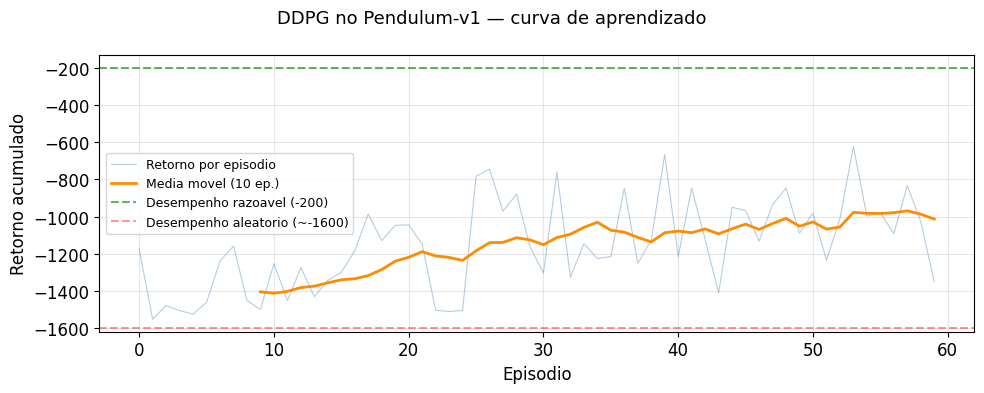

Gráfico salvo em nb05_ddpg_pendulum.png


In [11]:
# ── Curva de aprendizado DDPG ────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
fig.suptitle("DDPG no Pendulum-v1 — curva de aprendizado", fontsize=13)

ax.plot(hist_ddpg, alpha=0.4, color="steelblue", linewidth=0.8, label="Retorno por episodio")
if len(hist_ddpg) >= JANELA_MEDIA:
    mm = np.convolve(hist_ddpg, np.ones(JANELA_MEDIA)/JANELA_MEDIA, mode='valid')
    ax.plot(range(JANELA_MEDIA - 1, len(hist_ddpg)), mm,
            color="darkorange", linewidth=2, label=f"Media movel ({JANELA_MEDIA} ep.)")
ax.axhline(y=-200, color="green", linestyle="--", alpha=0.6, label="Desempenho razoavel (-200)")
ax.axhline(y=-1600, color="red",  linestyle="--", alpha=0.4, label="Desempenho aleatorio (~-1600)")
ax.set_xlabel("Episodio"); ax.set_ylabel("Retorno acumulado")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("nb05_ddpg_pendulum.png", dpi=100, bbox_inches="tight")
plt.show()
print("Gráfico salvo em nb05_ddpg_pendulum.png")

### Leitura da curva de aprendizado DDPG

**Escala de referência do Pendulum-v1:**
- Política aleatória: retorno ≈ −1.600 (pêndulo oscila sem controle)
- Desempenho razoável: retorno ≈ −200 (pêndulo próximo da posição vertical)
- Desempenho ótimo: retorno ≈ −120 a −150 (controle preciso com torque mínimo)

**O que a curva mostra com 60 episódios:** a tendência de melhora é visível, mas a convergência completa (≈−200) requer 300–500 episódios. Com os 60 episódios usados aqui (necessário para viabilizar CPU em ~3 min), o retorno final pode estar entre −1.000 e −600 com alta variância episódica — isso é esperado e não indica falha do algoritmo.

**Por que o retorno pode cair no final?** O DDPG sem buffer suficientemente preenchido pode "esquecer" políticas anteriores ao explorar estados novos. Uma queda no último episódio não significa regressão permanente — com mais episódios, a tendência geral continua positiva. O que importa é a **tendência da média móvel**, não o valor do último episódio isolado.

**Contraste com CartPole:** no CartPole (NB02–NB04), o agente recebe +1 a cada passo — sinal simples e frequente. No Pendulum, a recompensa é uma função quadrática contínua do ângulo e velocidade — muito mais difícil de otimizar, daí a convergência mais lenta mesmo com replay buffer.

## SAC — Soft Actor-Critic

O DDPG é eficaz, mas sensível à calibração do ruído de exploração (σ). Se σ for pequeno demais, a política fica presa em mínimos locais; grande demais, o sinal do ator é mascarado pelo ruído.

O SAC resolve isso de forma elegante: em vez de adicionar ruído *externamente*, a política aprende a ser **estocasticamente diversa** como parte do objetivo de treinamento. A exploração emerge naturalmente do processo de otimização — sem nenhum hiperparâmetro σ para calibrar.

### Diferenças de arquitetura em relação ao DDPG

| Componente | DDPG | SAC |
|---|---|---|
| Ator | Rede determinística + ruído externo | Rede Gaussiana (produz média + desvio-padrão) |
| Crítico | 1 rede Q | 2 redes Q independentes (double-Q trick) |
| Objetivo do ator | Maximizar Q(s, π(s)) | Maximizar Q(s, π(s)) − α·log π |
| Exploração | Ruído gaussiano fixo (σ=0.1) | Entropia da política (emerge do treinamento) |

**Por que dois críticos?** Com um único crítico, o ator pode explorar superestimações de Q — inventar ações "falsamente boas" onde o crítico errou. Usando dois críticos independentes e sempre tomando o mínimo `min(Q1, Q2)`, o ator não consegue explorar erros de estimação do crítico.

As duas células a seguir definem `AtorSAC` e `CriticoDuploSAC` — análogos ao que fizemos para o DDPG, mas com essas diferenças arquiteturais.

In [12]:
# ── SAC: implementação mínima do zero ───────────────────────────
# O SAC usa política Gaussiana com reparametrização e dois críticos.
# Não requer stable-baselines3.

LOG_STD_MIN, LOG_STD_MAX = -5, 2   # limites para estabilidade numérica do log_std


class AtorSAC(nn.Module):
    """Política Gaussiana: produz média e desvio-padrão da ação."""

    def __init__(self, n_obs, n_acoes, lim_acao):
        super().__init__()
        self.lim_acao = lim_acao
        self.tronco = nn.Sequential(
            nn.Linear(n_obs, 64), nn.ReLU(),
            nn.Linear(64, 64),   nn.ReLU(),
        )
        self.cabeca_media   = nn.Linear(64, n_acoes)
        self.cabeca_log_std = nn.Linear(64, n_acoes)

    def amostrar(self, obs):
        h       = self.tronco(obs)
        media   = self.cabeca_media(h)
        log_std = torch.clamp(self.cabeca_log_std(h), LOG_STD_MIN, LOG_STD_MAX)
        std     = log_std.exp()

        # Reparametrização: acao_raw = media + eps*std, eps ~ N(0,1)
        # Isso permite que o gradiente flua de volta pelos parâmetros do ator.
        dist    = torch.distributions.Normal(media, std)
        raw     = dist.rsample()
        acao    = torch.tanh(raw) * self.lim_acao

        # Correção do log_prob para a transformação tanh (mudança de variável).
        log_p   = dist.log_prob(raw) - torch.log(
            1 - (acao / self.lim_acao).pow(2) + 1e-7)
        return acao, log_p.sum(-1)


class CriticoDuploSAC(nn.Module):
    """Dois Q-networks independentes — usa o mínimo para evitar superestimação."""

    def __init__(self, n_obs, n_acoes):
        super().__init__()

        def _q():
            return nn.Sequential(
                nn.Linear(n_obs + n_acoes, 64), nn.ReLU(),
                nn.Linear(64, 64), nn.ReLU(),
                nn.Linear(64, 1),
            )

        self.q1, self.q2 = _q(), _q()

    def forward(self, obs, acao):
        x = torch.cat([obs, acao], dim=-1)
        return self.q1(x).squeeze(-1), self.q2(x).squeeze(-1)

    def min_q(self, obs, acao):
        return torch.min(*self.forward(obs, acao))


print("Arquitetura SAC definida.")
print("  AtorSAC         — política Gaussiana com reparametrização + correção de tanh")
print("  CriticoDuploSAC — dois Q-networks; usa o mínimo (double-Q trick)")

Arquitetura SAC definida.
  AtorSAC         — política Gaussiana com reparametrização + correção de tanh
  CriticoDuploSAC — dois Q-networks; usa o mínimo (double-Q trick)


Modelos SAC em: cuda:0
Treinamento SAC concluído.
  Episódio  10 | Retorno:  -1806.4
  Episódio  30 | Retorno:  -1149.5
  Episódio  50 | Retorno:   -965.6
  Episódio  60 | Retorno:  -1022.3


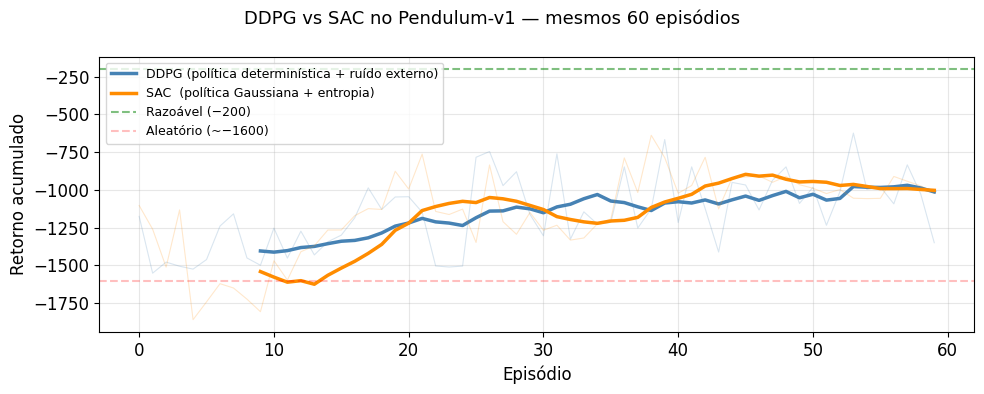


Retorno médio (últimos 10 ep.):
  DDPG : -1013.5
  SAC  : -1002.9
Nota: 60 ep. não é suficiente para convergência — a tendência da curva importa mais que o valor final.


In [13]:
# ── Treinamento SAC + comparação com DDPG ───────────────────────
# α=0.2 (temperatura fixa); pode ser aprendida automaticamente em implementações completas.
ALPHA_SAC = 0.2
LR_SAC    = 3e-4

env_sac = gym.make("Pendulum-v1")
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)

# Modelos movidos para o dispositivo selecionado (CPU ou GPU)
ator_sac         = AtorSAC(n_obs, n_acoes, lim_acao).to(dispositivo)
critico_sac      = CriticoDuploSAC(n_obs, n_acoes).to(dispositivo)
critico_sac_alvo = CriticoDuploSAC(n_obs, n_acoes).to(dispositivo)
critico_sac_alvo.load_state_dict(critico_sac.state_dict())

opt_ator_sac    = optim.Adam(ator_sac.parameters(),    lr=LR_SAC)
opt_critico_sac = optim.Adam(critico_sac.parameters(), lr=LR_SAC)
buffer_sac      = ReplayBuffer(BUFFER_SIZE)
hist_sac        = []

print(f"Modelos SAC em: {next(ator_sac.parameters()).device}")

for ep in range(N_EPISODIOS):   # mesmo N_EPISODIOS=60 do DDPG
    obs, _ = env_sac.reset(seed=SEED + ep)
    retorno_ep = 0.0

    for _ in range(MAX_PASSOS):
        # Ator amostra ação estocástica (política Gaussiana + reparametrização)
        obs_t = torch.tensor(obs, dtype=torch.float32).unsqueeze(0).to(dispositivo)
        with torch.no_grad():
            acao_t, _ = ator_sac.amostrar(obs_t)
        acao = acao_t.squeeze(0).cpu().numpy()  # retorna para numpy para o gym

        obs2, r, term, trunc, _ = env_sac.step(acao)
        buffer_sac.adicionar(obs, acao, r, obs2, term or trunc)
        obs = obs2; retorno_ep += r
        if term or trunc:
            break

        if len(buffer_sac) >= MIN_BUFFER:
            b_obs, b_ac, b_r, b_obs2, b_done = buffer_sac.amostrar(BATCH_SIZE)

            # Alvo do crítico: r + γ(1-d)(min_Q_alvo − α·log_π)
            with torch.no_grad():
                a2, logp2  = ator_sac.amostrar(b_obs2)
                q_alvo_sac = b_r + GAMMA * (1 - b_done) * (
                    critico_sac_alvo.min_q(b_obs2, a2) - ALPHA_SAC * logp2)

            q1p, q2p = critico_sac(b_obs, b_ac)
            perda_c  = (nn.functional.mse_loss(q1p, q_alvo_sac)
                      + nn.functional.mse_loss(q2p, q_alvo_sac))
            opt_critico_sac.zero_grad(); perda_c.backward(); opt_critico_sac.step()

            # Ator: maximiza  min_Q  −  α·log_π  (entropia incentivada)
            a_novo, logp_novo = ator_sac.amostrar(b_obs)
            perda_a = (ALPHA_SAC * logp_novo - critico_sac.min_q(b_obs, a_novo)).mean()
            opt_ator_sac.zero_grad(); perda_a.backward(); opt_ator_sac.step()

            atualizar_alvo(critico_sac, critico_sac_alvo, TAU)

    hist_sac.append(retorno_ep)

env_sac.close()
print("Treinamento SAC concluído.")
for ep_idx in [9, 29, 49, 59]:
    if ep_idx < len(hist_sac):
        print(f"  Episódio {ep_idx+1:3d} | Retorno: {hist_sac[ep_idx]:8.1f}")

# ── Comparação DDPG vs SAC ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
fig.suptitle("DDPG vs SAC no Pendulum-v1 — mesmos 60 episódios", fontsize=13)

for hist, nome, cor in [
    (hist_ddpg, "DDPG (política determinística + ruído externo)", "steelblue"),
    (hist_sac,  "SAC  (política Gaussiana + entropia)",           "darkorange"),
]:
    ax.plot(hist, alpha=0.2, color=cor, linewidth=0.8)
    if len(hist) >= JANELA_MEDIA:
        mm = np.convolve(hist, np.ones(JANELA_MEDIA) / JANELA_MEDIA, mode="valid")
        ax.plot(range(JANELA_MEDIA - 1, len(hist)), mm,
                color=cor, linewidth=2.5, label=nome)

ax.axhline(y=-200,  color="green", linestyle="--", alpha=0.5,  label="Razoável (−200)")
ax.axhline(y=-1600, color="red",   linestyle="--", alpha=0.25, label="Aleatório (~−1600)")
ax.set_xlabel("Episódio"); ax.set_ylabel("Retorno acumulado")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

media_sac  = np.mean(hist_sac[-10:])
media_ddpg = np.mean(hist_ddpg[-10:])
print(f"\nRetorno médio (últimos 10 ep.):")
print(f"  DDPG : {media_ddpg:.1f}")
print(f"  SAC  : {media_sac:.1f}")
print("Nota: 60 ep. não é suficiente para convergência — a tendência da curva importa mais que o valor final.")

## Bloco 4 — Interpretação pedagógica

### DDPG: o que diferencia do A2C

1. **Política determinística:** o ator produz diretamente o valor de torque — sem distribuição para amostrar. A exploração vem de ruído adicionado *externamente* durante a coleta.
2. ***Replay buffer* *off-policy*:** as transições `(s, a, r, s')` são armazenadas e reutilizadas em mini-batches. Isso quebra a correlação temporal e aumenta a eficiência amostral em relação aos métodos *on-policy* como REINFORCE e PPO.
3. **Redes-alvo:** sem a cópia suave (τ=0.005), o alvo de treinamento mudaria a cada passo — o crítico tentaria acertar um alvo em movimento. As redes-alvo convertem esse instável "alvo em fuga" em um alvo quase estático.

### SAC: exploração como objetivo, não como ruído

O SAC adiciona a entropia da política ao objetivo:
```
maximizar:  recompensa acumulada  +  α × entropia da política
```
Isso equivale a dizer: *o agente deve ser recompensado também por ser diverso nas suas ações.* A consequência prática é que o SAC explora mais uniformemente o espaço de estados e é muito menos sensível à escolha do sigma de ruído — porque ele não usa ruído externo.

**Double-Q trick:** o SAC usa dois críticos independentes e sempre toma o mínimo `min(Q1, Q2)` para calcular os alvos. Isso evita que o ator "invente" ações falsamente boas explorando superestimações do crítico — um problema frequente no DDPG.

### Comparação DDPG vs SAC

| Aspecto | DDPG | SAC |
|---|---|---|
| Tipo de política | Determinística | Estocástica (Gaussiana) |
| Exploração | Ruído externo (σ fixo) | Maximização de entropia |
| Temperatura α | Não se aplica | Fixo (α=0.2 neste notebook; aprendível em implementações completas) |
| Número de críticos | 1 | 2 (double-Q trick) |
| Robustez a hiperparâmetros | Moderada | Alta |

### Sobre o Pendulum-v1

O Pendulum-v1 é um pêndulo que precisa ser equilibrado na posição vertical. A recompensa penaliza ângulo, velocidade angular e torque aplicado — muito mais difícil de otimizar que o CartPole, daí a convergência mais lenta.

**Por que a curva tem tanta variância em 60 episódios?** Com poucos episódios, o replay buffer está pouco preenchido e os mini-batches são menos representativos. Com 300–500 episódios, a variância cai e a tendência de melhora fica clara. O que importa agora é a *tendência* da média móvel, não o valor do episódio final isolado.

## Autoavaliação

<details>
<summary>Pergunta 1: Por que o DDPG não usa argmax sobre Q(s,a) para espaços de ação contínuos?</summary>

**Resposta:** Em espaços de ação contínuos, não existe um conjunto finito de ações para enumerar — `argmax_a Q(s,a)` exigiria uma otimização interna cara a cada passo. O DDPG parametriza um ator determinístico μ(s;θ) treinado para maximizar Q(s, μ(s)). O gradiente de Q em relação à ação é propagado de volta para os parâmetros do ator via regra da cadeia, sem enumerar ações.

**Por quê:** O truque central do DDPG é usar o ator como "argmax diferenciável" — substituindo a operação discreta por uma rede neural treinável.

</details>

<details>
<summary>Pergunta 2: O que é entropia máxima (maximum entropy) e por que o SAC a incorpora no objetivo?</summary>

**Resposta:** O SAC maximiza J(π) = E[r] + α·E[H(π(·|s))], onde H é a entropia da distribuição de ações. Maximizar entropia incentiva o agente a ser tão aleatório quanto possível enquanto ainda obtém boa recompensa — promovendo exploração natural. α é o coeficiente de temperatura que equilibra recompensa e entropia; pode ser ajustado automaticamente.

**Por quê:** Entropia máxima torna o treinamento mais estável (políticas menos determinísticas são menos sensíveis a erros de estimação de Q) e o agente mais robusto a perturbações.

</details>

<details>
<summary>Pergunta 3: Qual é a vantagem prática do SAC sobre o DDPG?</summary>

**Resposta:** O SAC é muito mais estável — usa duas redes Q (para mitigação de overestimation via double Q-learning) e a entropia máxima reduz oscilações. O DDPG é sensível a hiperparâmetros e pode colapsar com ruído de exploração mal calibrado. O SAC também tem melhor transferência entre tarefas porque a política estocástica captura múltiplas boas soluções.

**Por quê:** O SAC foi criado justamente para endereçar a instabilidade do DDPG em ambientes de controle contínuo complexos. Na prática, SAC supera DDPG na maioria dos benchmarks contínuos.

</details>

## Experimento de modo de falha — Exploração no DDPG: sem ruído vs ruído excessivo

O DDPG depende de ruído externo para explorar. Sem ruído (`sigma=0`), a política determinística não consegue escapar do estado inicial. Com ruído excessivo (`sigma=2.0`), a exploração é tão intensa que mascara o sinal de aprendizado.

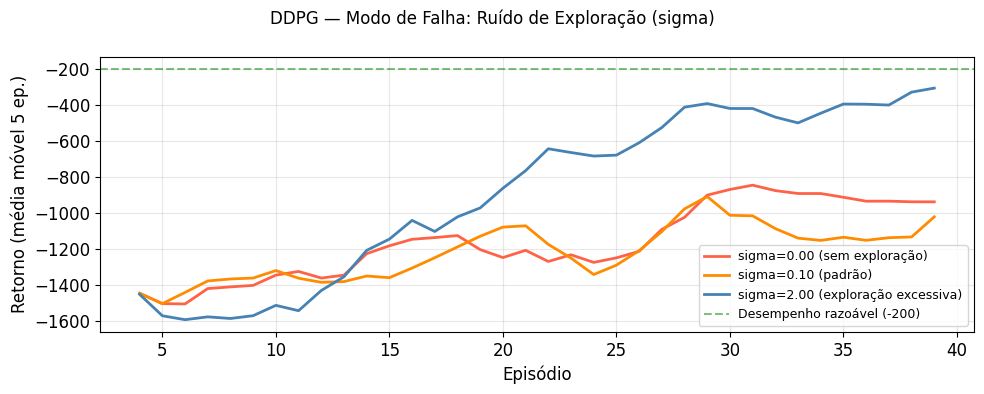

sigma=0.00: política determinística desde o início — fica presa no mesmo mínimo local.
sigma=2.00: ruído ≈ lim_acao — ações aleatórias mascaram completamente o sinal do ator.
sigma=0.10: exploração suficiente sem destruir o sinal de aprendizado.


In [14]:
import random as _random

N_EP_D3 = 40   # suficiente para ver o efeito; rápido em CPU

configs_sigma = [
    ("sigma=0.00 (sem exploração)",       0.00, "tomato"),
    ("sigma=0.10 (padrão)",               0.10, "darkorange"),
    ("sigma=2.00 (exploração excessiva)", 2.00, "steelblue"),
]

fig, ax = plt.subplots(figsize=(10, 4))
fig.suptitle("DDPG — Modo de Falha: Ruído de Exploração (sigma)", fontsize=12)

env_d3 = gym.make("Pendulum-v1")
for nome, sigma_val, cor in configs_sigma:
    torch.manual_seed(SEED); np.random.seed(SEED); _random.seed(SEED)
    # Todos os modelos movidos para o dispositivo selecionado
    a_d3  = AtorDDPG(n_obs, n_acoes, lim_acao).to(dispositivo)
    at_d3 = AtorDDPG(n_obs, n_acoes, lim_acao).to(dispositivo)
    c_d3  = CriticoDDPG(n_obs, n_acoes).to(dispositivo)
    ct_d3 = CriticoDDPG(n_obs, n_acoes).to(dispositivo)
    at_d3.load_state_dict(a_d3.state_dict())
    ct_d3.load_state_dict(c_d3.state_dict())
    oa = optim.Adam(a_d3.parameters(),  lr=LR_ATOR)
    oc = optim.Adam(c_d3.parameters(), lr=LR_CRITICO)
    buf_d3 = ReplayBuffer(BUFFER_SIZE)
    rng_d3 = np.random.default_rng(SEED)
    hist_d3 = []

    for ep in range(N_EP_D3):
        obs_ep, _ = env_d3.reset(seed=SEED + ep)
        ret_ep = 0.0
        for _ in range(MAX_PASSOS):
            obs_t = torch.tensor(obs_ep, dtype=torch.float32).to(dispositivo)
            with torch.no_grad():
                a = a_d3(obs_t).cpu().numpy()  # GPU → numpy para o gym
            a = np.clip(a + rng_d3.normal(0, sigma_val, size=a.shape), -lim_acao, lim_acao)
            obs2, r, term, trunc, _ = env_d3.step(a)
            buf_d3.adicionar(obs_ep, a, r, obs2, term or trunc)
            obs_ep = obs2; ret_ep += r
            if term or trunc: break
            if len(buf_d3) >= MIN_BUFFER:
                b_o, b_a, b_r, b_o2, b_d = buf_d3.amostrar(BATCH_SIZE)
                with torch.no_grad():
                    q_t = b_r + GAMMA * (1 - b_d) * ct_d3(b_o2, at_d3(b_o2))
                p_c = nn.functional.mse_loss(c_d3(b_o, b_a), q_t)
                oc.zero_grad(); p_c.backward(); oc.step()
                p_a = -c_d3(b_o, a_d3(b_o)).mean()
                oa.zero_grad(); p_a.backward(); oa.step()
                atualizar_alvo(a_d3, at_d3, TAU); atualizar_alvo(c_d3, ct_d3, TAU)
        hist_d3.append(ret_ep)

    JANELA = 5
    mm = np.convolve(hist_d3, np.ones(JANELA)/JANELA, mode='valid')
    ax.plot(range(JANELA - 1, len(hist_d3)), mm, color=cor, linewidth=2, label=nome)

env_d3.close()
ax.axhline(y=-200, color="green", linestyle="--", alpha=0.5, label="Desempenho razoável (-200)")
ax.set_xlabel("Episódio"); ax.set_ylabel("Retorno (média móvel 5 ep.)")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("sigma=0.00: política determinística desde o início — fica presa no mesmo mínimo local.")
print("sigma=2.00: ruído ≈ lim_acao — ações aleatórias mascaram completamente o sinal do ator.")
print("sigma=0.10: exploração suficiente sem destruir o sinal de aprendizado.")

### Diagnóstico: o que cada valor de sigma revela

| `sigma` | Comportamento observado | Causa |
|---|---|---|
| `0.00` (sem ruído) | Curva plana em ~−1.500 desde o início | Política determinística repete as mesmas ações iniciais — fica presa em mínimo local sem nunca explorar |
| `0.10` (padrão) | Melhora gradual visível a partir do ep 20–30 | Exploração suficiente para descobrir regiões do espaço de estados com recompensa melhor |
| `2.00` (ruído excessivo) | Curva igualmente plana em ~−1.500 | Ruído ≈ `lim_acao` — as ações do ator são completamente mascaradas pelo ruído; o agente age de forma aleatória |

**O insight central:** sem exploração, o DDPG não aprende nada. Com exploração excessiva, também não. O `sigma` precisa ser calibrado para que o agente visite estados novos sem destruir o sinal do ator aprendido. Esse problema não existe no SAC — a exploração é endógena ao objetivo de maximização de entropia, tornando o algoritmo muito menos sensível a este hiperparâmetro.

## Benchmark de referência — DDPG e SAC no Pendulum-v1

Como o DDPG obtido se compara com SAC e com os limiares da literatura para o Pendulum-v1?

**Contexto de execução:** este notebook usa 60 episódios (CPU, ~3 min). Convergência completa do DDPG requer ~300 episódios (60k passos). A tabela abaixo mostra os retornos esperados com treino completo — não os valores desta execução parcial.

In [15]:
media_ddpg_final = np.mean(hist_ddpg[-10:])
media_sac_final  = np.mean(hist_sac[-10:])

print("Benchmark — DDPG e SAC no Pendulum-v1")
print("=" * 64)
print()
print(f"{'Referência':<50} {'Retorno médio'}")
print("─" * 67)
print(f"  {'Política aleatória (baseline)':<48} ~-1600")
print(f"  {'DDPG — este notebook (últimos 10 ep.)':<48} {media_ddpg_final:.0f}")
print(f"  {'SAC  — este notebook (últimos 10 ep.)':<48} {media_sac_final:.0f}")
print(f"  {'DDPG convergido (300-500 ep., GPU)':<48} ~-200 a -300")
print(f"  {'SAC (Haarnoja et al. 2018, Pendulum)':<48} ~-150 a -200")
print(f"  {'Desempenho razoável (referência didática)':<48} -200")
print()
print(f"Contexto: {N_EPISODIOS} ep × {MAX_PASSOS} passos = {N_EPISODIOS*MAX_PASSOS:,} passos (CPU, ~5 min)")
print("Convergência completa exige ~300 ep. (60k passos) — a tendência já é visível.")
print()
print("Para controle contínuo em produção: SAC é o ponto de partida recomendado.")

Benchmark — DDPG e SAC no Pendulum-v1

Referência                                         Retorno médio
───────────────────────────────────────────────────────────────────
  Política aleatória (baseline)                    ~-1600
  DDPG — este notebook (últimos 10 ep.)            -1013
  SAC  — este notebook (últimos 10 ep.)            -1003
  DDPG convergido (300-500 ep., GPU)               ~-200 a -300
  SAC (Haarnoja et al. 2018, Pendulum)             ~-150 a -200
  Desempenho razoável (referência didática)        -200

Contexto: 60 ep × 200 passos = 12,000 passos (CPU, ~5 min)
Convergência completa exige ~300 ep. (60k passos) — a tendência já é visível.

Para controle contínuo em produção: SAC é o ponto de partida recomendado.


## Bloco 5 — Limites e próximo passo

DDPG e SAC representam o estado da arte para **controle contínuo com RL profundo**, mas ainda têm limitações:

| Limitação | Causa |
|---|---|
| Ineficiência para recompensas esparsas | Dependem de muitas interações para sinal de aprendizado |
| Difícil transferência entre tarefas | Política específica para um ambiente |
| Sem modelo do ambiente | Não exploram conhecimento estrutural (*model-based RL*) |

**Próximo notebook:** `aula03_06_comparativo_final.ipynb` — consolidação das duas grandes famílias de métodos (value-based vs policy-based) e transição para a Aula 04.

In [16]:
# Glossário dos termos técnicos deste notebook
rl_utils.exibir_glossario([
    'DDPG', 'SAC', 'entropy', 'replay buffer', 'target network',
    'policy gradient', 'advantage function',
])

Termo (EN)           Tradução (PT)                Descrição
------------------------------------------------------------------------------------------------------------
DDPG                 DDPG                         Deep Deterministic Policy Gradient — política determinística para espaços contínuos.
SAC                  SAC                          Soft Actor-Critic — maximiza recompensa e entropia da política.
advantage function   função de vantagem           A(s,a) = Q(s,a) − V(s) — mede o ganho relativo de uma ação.
entropy              entropia                     Medida de aleatoriedade da política; regulariza exploração no SAC.
policy gradient      gradiente de política        Família de métodos que otimiza diretamente os parâmetros da política.
replay buffer        buffer de replay             Memória que armazena transições para treinamento em mini-batches.
target network       rede-alvo                    Cópia estável da rede principal usada para calcular alvos de treiname

## Leituras e referências

- Lillicrap, T. P., et al. (2015). Continuous Control with Deep Reinforcement Learning (DDPG). *arXiv:1509.02971*. Disponível em: https://arxiv.org/abs/1509.02971. Acesso em: abril 2026.
- Haarnoja, T., Zhou, A., Abbeel, P., & Levine, S. (2018). Soft Actor-Critic: Off-Policy Maximum Entropy Deep Reinforcement Learning with a Stochastic Actor. *arXiv:1801.01290*. Disponível em: https://arxiv.org/abs/1801.01290. Acesso em: abril 2026.
- Farama Foundation. *Gymnasium documentation — Pendulum-v1*. Disponível em: https://gymnasium.farama.org/environments/classic_control/pendulum/. Acesso em: abril 2026.